# Calculating Thermodynamic Properties with KBPipeline
*A step-by-step tutorial for processing simulation data using Ethanol-Water mixtures.*

In [1]:
from pathlib import Path

from kbkit.api import Pipeline

In [2]:
# create & run pipeline

pipe = Pipeline(
    pure_path="./test_data/pure_components",  # path to parent directory containing pure-component subdirectories
    pure_systems=["ETHOL_300", "SPCEW_300"],  # pure-component subdirectories
    base_path="./test_data/ethanol_water_26C",  # path to parent directory containing mixture subdirectories
    rdf_dir="kbi_rdf_files",  # name for rdf-file subdirectory in each mixture directory (this needs to be the same in each system.)
    start_time=10000,  # start time (ps) for calculating MD properties (from energy file)
    include_mode="npt",  # string required in MD output files to be a 'valid' filename
    errors="warn",  # print ConvergenceError (do not raise!)
    molecule_map={
        "ETHOL": "ethanol",
        "SPCEW": "water",
    },  # map molecule types in GROMACS files to molecule name for figures
)

In [3]:
# get PropertyResult objects from KBI-derived thermodynamics and MD simulation properties
results = pipe.results

# view attributes
print(list(results.keys()))

['molecules', 'n_i', 'n_sys', 'x', 'simulated_temperature', 'ideal_temperature', 'excess_temperature', 'simulated_pressure', 'ideal_pressure', 'excess_pressure', 'simulated_density', 'ideal_density', 'excess_density', 'simulated_volume', 'ideal_volume', 'excess_volume', 'simulated_potential', 'ideal_potential', 'excess_potential', 'simulated_kinetic_en', 'ideal_kinetic_en', 'excess_kinetic_en', 'simulated_total_energy', 'ideal_total_energy', 'excess_total_energy', 'simulated_enthalpy', 'ideal_enthalpy', 'excess_enthalpy', 'simulated_cp', 'ideal_cp', 'excess_cp', 'simulated_cv', 'ideal_cv', 'excess_cv', 'simulated_isothermal_compressibility', 'ideal_isothermal_compressibility', 'excess_isothermal_compressibility', 'simulated_number_density', 'ideal_number_density', 'excess_number_density', 'simulated_molar_volume', 'ideal_molar_volume', 'excess_molar_volume', 'A', 'B', 'Gamma', 'H', 'M', 'det_H', 'dlngamma_dxi', 'dmu_dxi', 'g_ex', 'g_id', 'g_mix', 'h_mix', 'i0', 'i0_kappa', 'i0_p', 'i0_

In [4]:
# convert property to desired unit

# PropertyResult contain attributes: name, value, units, type(for MD properties only)
results["excess_molar_volume"].to("cm^3/mol")

PropertyResult(name='excess_molar_volume', shape=(12,), units='cm^3/mol', type='excess')

In [5]:
# another example using unit conversions: Excess Gibbs Energy kJ/mol & kcal/mol

gibbs_ex_kJ_mol = results["g_ex"].to("kJ/mol")
gibbs_ex_kcal_mol = results["g_ex"].to("kcal/mol")

print(f"G^E (kJ/mol): {gibbs_ex_kJ_mol.value}")
print(f"G^E (kcal/mol): {gibbs_ex_kcal_mol.value}")

G^E (kJ/mol): [0.         0.15154389 0.26923459 0.39489394 0.52031235 0.63897791
 0.73698322 0.79515589 0.77185588 0.58206202 0.20763915 0.        ]
G^E (kcal/mol): [0.         0.03621986 0.06434861 0.09438192 0.12435764 0.15271938
 0.17614322 0.19004682 0.18447798 0.13911616 0.04962695 0.        ]


In [6]:
# to get KBI values
kbis = pipe.kbi_res.to("cm^3/mol")
kbis

PropertyResult(name='kbi', shape=(12, 2, 2), units='cm^3/mol')

In [7]:
# we can use the KBI object to extract individual KBIntegrator objects for system & mol-names
kbint_obj = kbis.metadata["sys_406"][("ETHOL", "SPCEW")]
kbint_obj

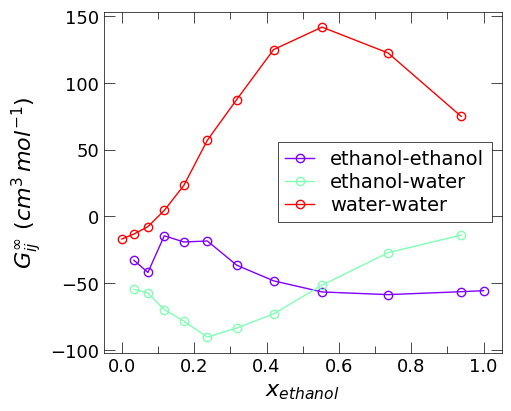

In [8]:
# we can access plotter classes to make individual figures

# get index of ETHOL (ethanol)
idx_eth = pipe.systems.get_mol_index("ETHOL")
# get mole fractions of ETHOL
x_eth = pipe.systems.x[:, idx_eth]

# note: this takes in any argument that you would give plt.plot()
pipe.kbi_plotter.plot_composition(
    x=x_eth,
    molecules=[pipe.molecule_map[mol] for mol in pipe.systems.molecules],
    xlab=r"$x_{ethanol}$",
    cmap="rainbow",
    marker="o",
    ls="-",
    lw=1,
    mew=1,
)

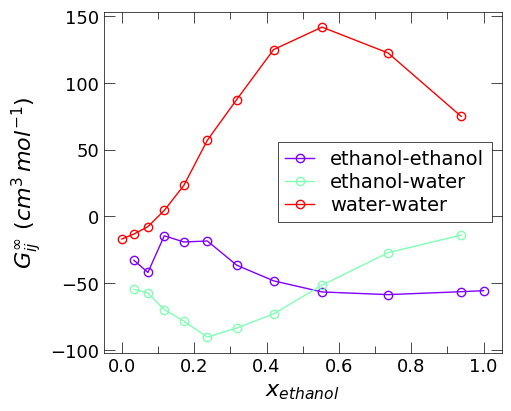

In [9]:
# alternatively, we can plot the same thing with ThermoPlotter & different arguments
# for thermo plotter; it will find the mole fractions corresponding to 'xmol'
pipe.thermo_plotter.plot_property(
    "kbi",
    units="cm^3/mol",
    ylabel=r"$G_{ij}^{\infty}$",
    xmol="ETHOL",
    cmap="rainbow",
    marker="o",
    lw=1,
    mew=1,
    figsize=(5, 4),
)

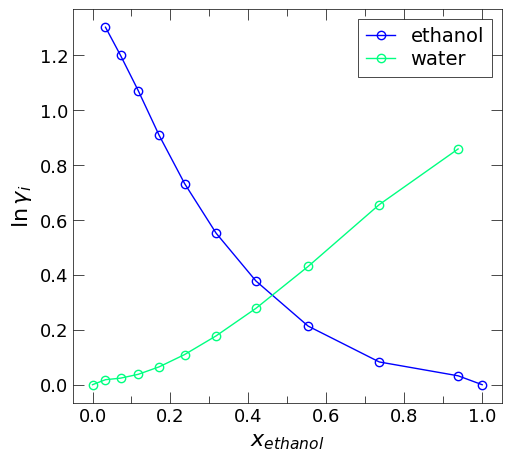

In [10]:
# ThermoPlotter is also used to plot variables in KBThermo or pipe.thermo
# note: property name matches those in pipe.results keys

pipe.thermo_plotter.plot_property(
    "lngamma", ylabel=r"$\ln \gamma_i$", xmol="ETHOL", lw=1, marker="o", mew=1, cmap="winter"
)

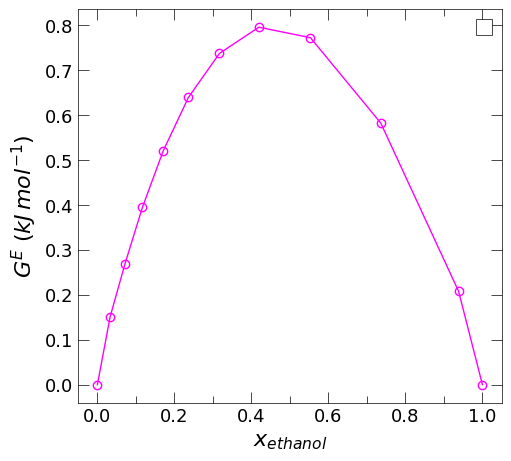

In [11]:
# Use ThermoPlotter to plot excess gibbs energy in kJ/mol

pipe.thermo_plotter.plot_property(
    "g_ex", units="kJ/mol", ylabel=r"$G^E$", xmol="ETHOL", lw=1, marker="o", mew=1, cmap="spring"
)

In [12]:
# to make all figures --- includes KBI calculations and thermodynamic analysis

figpath = Path("./figures/kb_analysis")
figpath.mkdir(exist_ok=True, parents=True)

pipe.make_figures(xmol="ETHOL", ls="", mew=1.2, marker="o", savepath=figpath)

## Create figures for *KBKit* paper

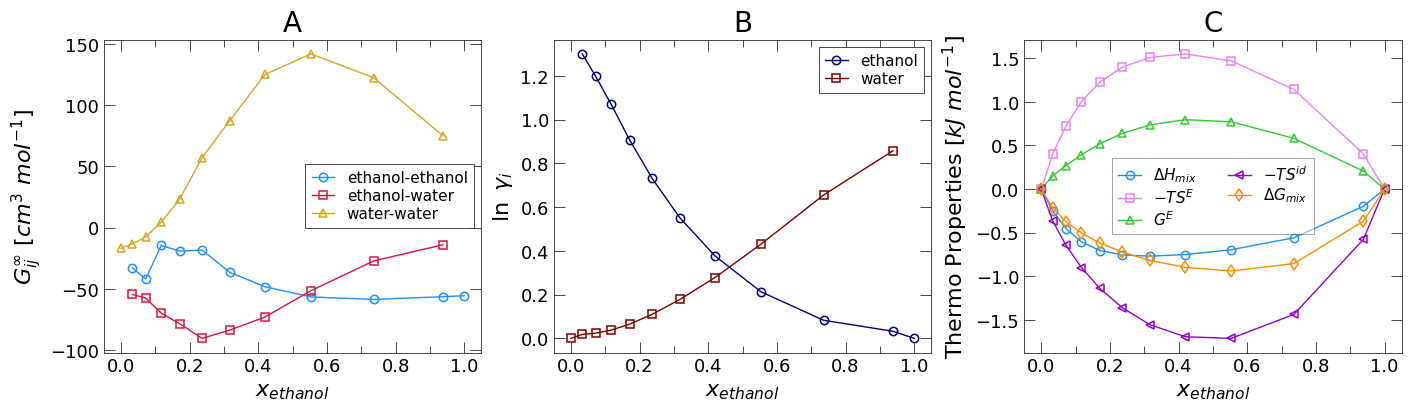

In [13]:
kbis_cm3_mol = pipe.kbi_res.to("cm^3/mol").value
molmap = pipe.molecule_map
mols = pipe.systems.molecules
idx = pipe.systems.get_mol_index("ETHOL")
x_ext = pipe.systems.x[:, idx]

import numpy as np

from kbkit.visualization.format import *

fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for axx in ax:
    style_axes(axx, minorxticks=np.arange(0, 1, 0.1))

lw = 1
mew = 1.1
ls = "-"

ax[0].set_xlabel(r"$x_{{ethanol}}$")
ax[0].set_ylabel(r"$G_{{ij}}^\infty$ [$cm^3$ $mol^{{-1}}$]")
ax[0].plot(
    x_ext,
    kbis_cm3_mol[:, 0, 0],
    c="dodgerblue",
    marker="o",
    lw=lw,
    mew=mew,
    ls=ls,
    label=f"{molmap[mols[0]]}-{molmap[mols[0]]}",
)
ax[0].plot(
    x_ext,
    kbis_cm3_mol[:, 0, 1],
    c="crimson",
    marker="s",
    lw=lw,
    mew=mew,
    ls=ls,
    label=f"{molmap[mols[0]]}-{molmap[mols[1]]}",
)
ax[0].plot(
    x_ext,
    kbis_cm3_mol[:, 1, 1],
    c="goldenrod",
    marker="^",
    lw=lw,
    mew=mew,
    ls=ls,
    label=f"{molmap[mols[1]]}-{molmap[mols[1]]}",
)
style_legend(ax[0], ncol=1, fontsize=11, framealpha=1)

ax[0].set_xlim(-0.05, 1.05)

ax[1].set_xlabel(r"$x_{{ethanol}}$")
ax[1].set_ylabel(r"$\ln \ \gamma_i$")
ac = pipe.thermo.lngamma()
ax[1].plot(x_ext, ac[:, 0], c="navy", marker="o", lw=lw, mew=mew, ls=ls, label=f"{molmap[mols[0]]}")
ax[1].plot(x_ext, ac[:, 1], c="maroon", marker="s", lw=lw, mew=mew, ls=ls, label=f"{molmap[mols[1]]}")
style_legend(ax[1], ncol=1, fontsize=11, framealpha=1)

ax[2].set_xlabel(r"$x_{{ethanol}}$")
ax[2].set_ylabel(r"Thermo Properties [$kJ$ $mol^{{-1}}$]")
ax[2].plot(x_ext, pipe.thermo.h_mix(), c="dodgerblue", marker="o", lw=lw, mew=mew, ls=ls, label=r"$\Delta H_{{mix}}$")
ax[2].plot(x_ext, -300 * pipe.thermo.s_ex(), c="violet", marker="s", lw=lw, mew=mew, ls=ls, label=r"$-TS^E$")
ax[2].plot(x_ext, pipe.thermo.g_ex(), c="limegreen", marker="^", lw=lw, mew=mew, ls=ls, label=r"$G^E$")
ax[2].plot(x_ext, pipe.thermo.g_id(), c="darkviolet", marker="<", lw=lw, mew=mew, ls=ls, label=r"$-TS^{id}$")
ax[2].plot(x_ext, pipe.thermo.g_mix(), c="darkorange", marker="d", lw=lw, mew=mew, ls=ls, label=r"$\Delta G_{{mix}}$")
style_legend(ax[2], ncol=2, fontsize=11, framealpha=0.5)

ax[0].set_title("A", fontsize=20)
ax[1].set_title("B", fontsize=20)
ax[2].set_title("C", fontsize=20)
fig.savefig("figures/pipeline_kbi_thermo.pdf", dpi=100)

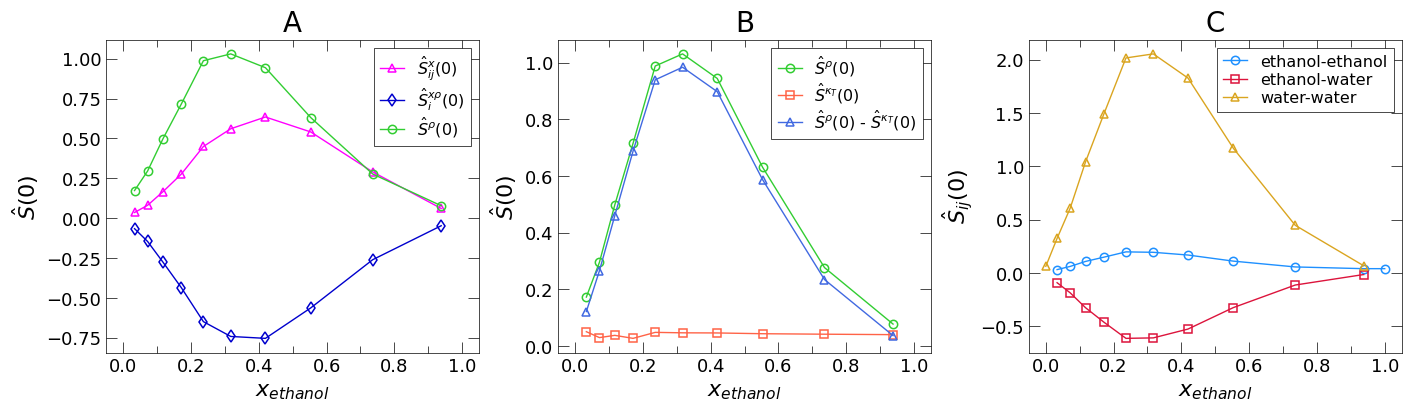

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for axx in ax:
    style_axes(axx, minorxticks=np.arange(0, 1, 0.1))
ax[0].set_xlim(-0.05, 1.05)

ax[0].plot(
    x_ext, pipe.thermo.s0_x()[:, 0, 0], marker="^", lw=lw, mew=mew, ls=ls, c="magenta", label=r"$\hat{S}_{ij}^{x}(0)$"
)
ax[0].plot(
    x_ext,
    pipe.thermo.s0_xp()[:, 0],
    marker="d",
    lw=lw,
    mew=mew,
    ls=ls,
    c="mediumblue",
    label=r"$\hat{S}_{i}^{x\rho}(0)$",
)
ax[0].plot(x_ext, pipe.thermo.s0_p(), marker="o", lw=lw, mew=mew, ls=ls, c="limegreen", label=r"$\hat{S}^{\rho}(0)$")
style_legend(ax[0], ncol=1, fontsize=11.5)
ax[0].set_xlabel(r"$x_{{ethanol}}$")
ax[0].set_ylabel(r"$\hat{S}(0)$")

ax[1].plot(x_ext, pipe.thermo.s0_p(), marker="o", lw=lw, mew=mew, ls=ls, c="limegreen", label=r"$\hat{S}^{\rho}(0)$")
ax[1].plot(
    x_ext, pipe.thermo.s0_kappa(), marker="s", lw=lw, mew=mew, ls=ls, c="tomato", label=r"$\hat{S}^{\kappa_T}(0)$"
)
ax[1].plot(
    x_ext,
    pipe.thermo.s0_p() - pipe.thermo.s0_kappa(),
    marker="^",
    lw=lw,
    mew=mew,
    ls=ls,
    c="royalblue",
    label=r"$\hat{S}^{\rho}(0)$ - $\hat{S}^{\kappa_T}(0)$",
)

style_legend(ax[1], ncol=1, fontsize=11.5)
ax[1].set_xlabel(r"$x_{{ethanol}}$")
ax[1].set_ylabel(r"$\hat{S}(0)$")

mol0, mol1 = [pipe.molecule_map[mol] for mol in pipe.systems.molecules]

ax[2].plot(
    x_ext, pipe.thermo.s0_ij()[:, 0, 0], marker="o", lw=lw, mew=mew, ls=ls, c="dodgerblue", label=f"{mol0}-{mol0}"
)
ax[2].plot(x_ext, pipe.thermo.s0_ij()[:, 0, 1], marker="s", lw=lw, mew=mew, ls=ls, c="crimson", label=f"{mol0}-{mol1}")
ax[2].plot(
    x_ext, pipe.thermo.s0_ij()[:, 1, 1], marker="^", lw=lw, mew=mew, ls=ls, c="goldenrod", label=f"{mol1}-{mol1}"
)
style_legend(ax[2], ncol=1, fontsize=11.5)
ax[2].set_xlabel(r"$x_{{ethanol}}$")
ax[2].set_ylabel(r"$\hat{S}_{ij}(0)$")

ax[0].set_title("A", fontsize=20)
ax[1].set_title("B", fontsize=20)
ax[2].set_title("C", fontsize=20)

fig.savefig("figures/pipeline_structure_factors.pdf", dpi=100)

### Flowchart Images

These cells demonstrate how to extract data from the `KBPipeline` and format figures.

In [15]:
x = results["x"].value
kbi = results["kbi"].to("cm^3/mol").value
s0_x = results["s0_x"].value[:, 0, 0]
s0_xp = results["s0_xp"].value[:, 0]
s0_p = results["s0_p"].value
ln_gamma = results["lngamma"].value
hmix = results["h_mix"].to("kJ/mol").value
ge = results["g_ex"].to("kJ/mol").value
se = results["s_ex"].to("kJ/mol/K").value
T = results["simulated_temperature"].value

In [16]:
import numpy as np

figsize = (5, 4)
cmap = "gnuplot2"

colors = plt.colormaps[cmap](np.linspace(0.2, 1, 4))
i1 = list(results["molecules"].value).index("ETHOL")
x1 = x[:, i1]

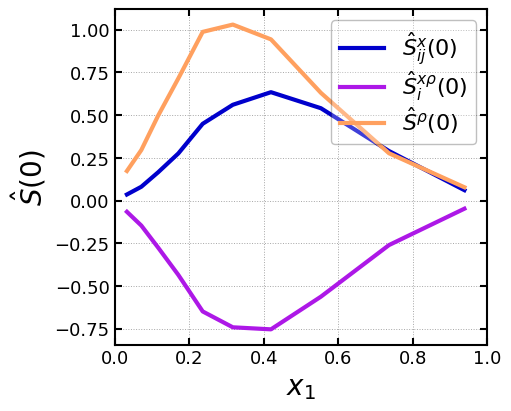

In [17]:
fig, ax = plt.subplots(figsize=figsize)
ax.plot(x1, s0_x, lw=3, color=colors[0], label=r"$\hat{S}_{ij}^x$(0)")
ax.plot(x1, s0_xp, lw=3, color=colors[1], label=r"$\hat{S}_{i}^{x\rho}$(0)")
ax.plot(x1, s0_p, lw=3, color=colors[2], label=r"$\hat{S}^\rho$(0)")
ax.legend(fontsize=16, framealpha=0.25)
ax.set_xlim(0, 1)
ax.set_xlabel(r"$x_1$", fontsize=20)
ax.set_ylabel(r"$\hat{S}$(0)", fontsize=20)
fig.savefig("./flowchart_imgs/bh_s0.pdf", dpi=100, transparent=True)

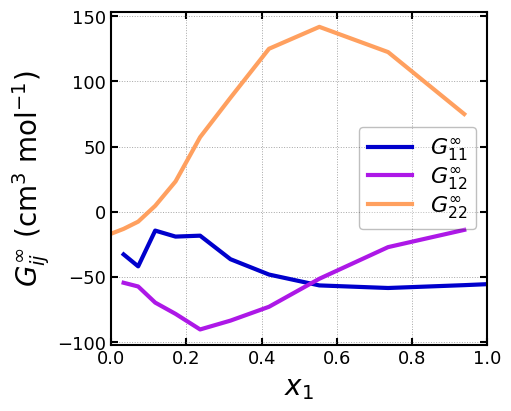

In [18]:
fig, ax = plt.subplots(figsize=figsize)
ax.plot(x1, kbi[:, 0, 0], lw=3, color=colors[0], label=r"$G_{11}^\infty$")
ax.plot(x1, kbi[:, 0, 1], lw=3, color=colors[1], label=r"$G_{12}^\infty$")
ax.plot(x1, kbi[:, 1, 1], lw=3, color=colors[2], label=r"$G_{22}^\infty$")
ax.legend(fontsize=16, framealpha=0.25)
ax.set_xlim(0, 1)
ax.set_xlabel(r"$x_1$", fontsize=20)
ax.set_ylabel(r"$G_{ij}^\infty$ (cm$^3$ mol$^{-1}$)", fontsize=20)
fig.savefig("./flowchart_imgs/kbis.pdf", dpi=100, transparent=True)

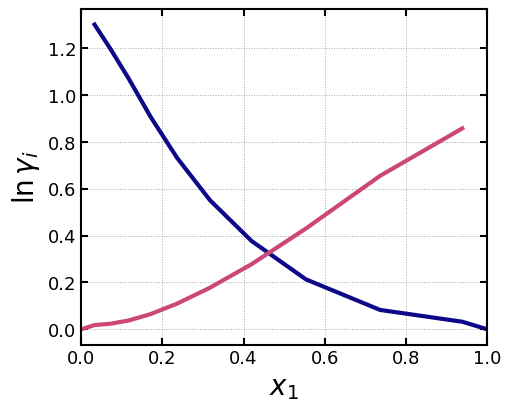

In [19]:
fig, ax = plt.subplots(figsize=figsize)
colors_2 = plt.colormaps["plasma"](np.linspace(0, 1, 3))
ax.plot(x1, ln_gamma[:, 0], lw=3, color=colors_2[0])
ax.plot(x1, ln_gamma[:, 1], lw=3, color=colors_2[1])
ax.set_xlim(0, 1)
ax.set_xlabel(r"$x_1$", fontsize=20)
ax.set_ylabel(r"$\ln \gamma_i$", fontsize=20)
fig.savefig("./flowchart_imgs/lngammas.pdf", dpi=100, transparent=True)

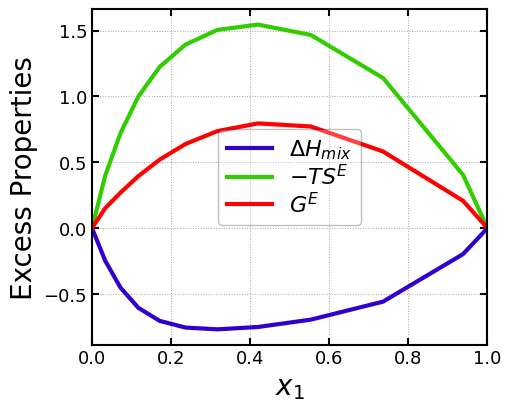

In [20]:
fig, ax = plt.subplots(figsize=figsize)
colors_3 = plt.colormaps["brg"](np.linspace(0.1, 0.9, 3))
ax.plot(x1, hmix, lw=3, color=colors_3[0], label=r"$\Delta H_{mix}$")
ax.plot(x1, -T * se, lw=3, color=colors_3[2], label=r"$-TS^E$")
ax.plot(x1, ge, lw=3, color=colors_3[1], label=r"$G^E$")
ax.legend(fontsize=16, framealpha=0.25)
ax.set_xlim(0, 1)
ax.set_xlabel(r"$x_1$", fontsize=20)
ax.set_ylabel(r"Excess Properties", fontsize=20)
fig.savefig("./flowchart_imgs/excess_props.pdf", dpi=100, transparent=True)

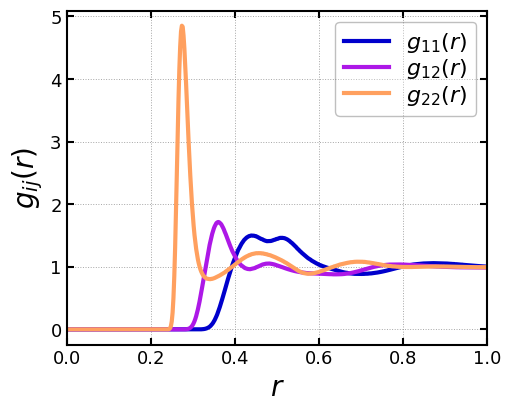

In [21]:
syspath = Path("./test_data/ethanol_water_26C/sys_405")
rdfpath = next(syspath.glob("*rdf*"))

import itertools

from natsort import natsorted

from kbkit.io import RdfParser

combos_all = list(itertools.product(range(2), range(2)))
combos = [(i, j) for (i, j) in combos_all if i <= j]

fig, ax = plt.subplots(figsize=figsize)
for ii, f in enumerate(natsorted(rdfpath.glob("*.xvg"))):
    rdf = RdfParser(f)
    i, j = combos[ii]
    ax.plot(rdf.r, rdf.gr, lw=3, color=colors[ii], label=rf"$g_{{{i + 1}{j + 1}}}(r)$")
ax.legend(fontsize=16, framealpha=0.25)
ax.set_xlim(0, 1)
ax.set_xlabel(r"$r$", fontsize=20)
ax.set_ylabel(r"$g_{ij}(r)$", fontsize=20)
fig.savefig("./flowchart_imgs/rdfs.pdf", dpi=100, transparent=True)